<a href="https://colab.research.google.com/github/kdp-2005/krunalcodealpha-/blob/main/Sentiment%20Analysis%20On%20Amazon%20Rating.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import re

import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving amazon.csv to amazon.csv


In [ ]:
df = pd.read_csv(list(uploaded.keys())[0])

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (1465, 16)


,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


In [ ]:
print(df.columns)

Index(['product_id', 'product_name', 'category', 'discounted_price',
       'actual_price', 'discount_percentage', 'rating', 'rating_count',
       'about_product', 'user_id', 'user_name', 'review_id', 'review_title',
       'review_content', 'img_link', 'product_link'],
      dtype='object')


In [ ]:
df = df[[
    'product_name',
    'rating',
    'review_title',
    'review_content'
]]

df.dropna(inplace=True)

print(df.shape)

(1465, 4)


In [ ]:
def clean_text(text):

    text = str(text).lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"[^a-zA-Z\s]", "", text)

    text = re.sub(r"\s+", " ", text)

    return text.strip()

df["clean_review"] = df["review_content"].apply(clean_text)

df.head()

,product_name,rating,review_title,review_content,clean_review
0,Wayona Nylon Braided USB to Lightning Fast Cha...,4.2,"Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,looks durable charging is fine toono complains...
1,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,4.0,"A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,i ordered this cable to connect my phone to an...
2,Sounce Fast Phone Charging Cable & Data Sync U...,3.9,"Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",not quite durable and sturdy good nice product...
3,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,4.2,"Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",good productlong wirecharges goodnicei bought ...
4,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,4.2,"As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",bought this instead of original apple does the...


In [ ]:
sia = SentimentIntensityAnalyzer()

def classify_sentiment(text):

    score = sia.polarity_scores(text)["compound"]

    if score >= 0.05:
        return "Positive"

    elif score <= -0.05:
        return "Negative"

    else:
        return "Neutral"

df["Sentiment"] = df["clean_review"].apply(classify_sentiment)

df.head()

,product_name,rating,review_title,review_content,clean_review,Sentiment
0,Wayona Nylon Braided USB to Lightning Fast Cha...,4.2,"Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,looks durable charging is fine toono complains...,Positive
1,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,4.0,"A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,i ordered this cable to connect my phone to an...,Positive
2,Sounce Fast Phone Charging Cable & Data Sync U...,3.9,"Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",not quite durable and sturdy good nice product...,Positive
3,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,4.2,"Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",good productlong wirecharges goodnicei bought ...,Positive
4,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,4.2,"As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",bought this instead of original apple does the...,Positive


In [ ]:
sentiment_counts = df["Sentiment"].value_counts()

print(sentiment_counts)

Sentiment
Positive    1381
Negative      74
Neutral       10
Name: count, dtype: int64


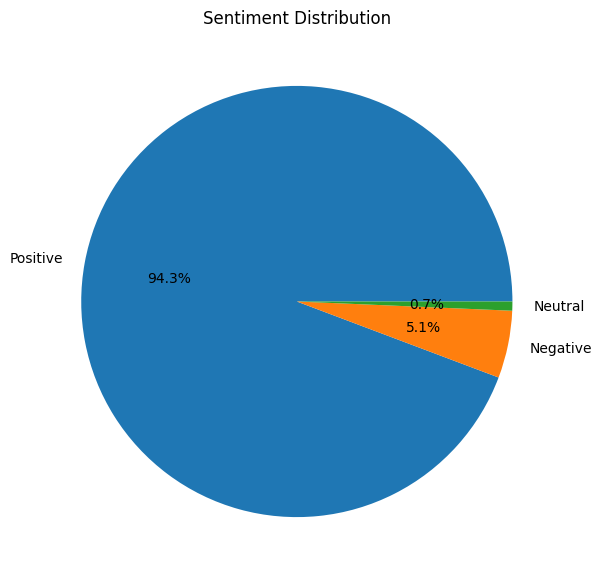

In [ ]:
plt.figure(figsize=(7,7))

plt.pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    autopct="%1.1f%%"
)

plt.title("Sentiment Distribution")

plt.show()

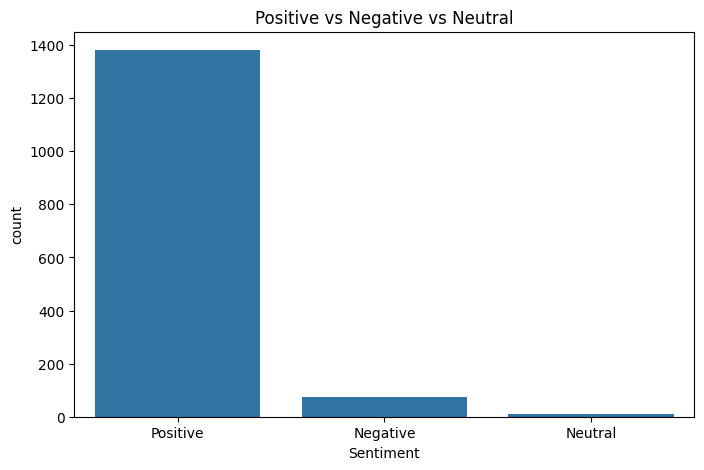

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Sentiment"
)

plt.title("Positive vs Negative vs Neutral")

plt.show()

In [ ]:
df["Scores"] = df["clean_review"].apply(
    lambda x: sia.polarity_scores(x)
)

df["Positive_Score"] = df["Scores"].apply(lambda x: x["pos"])

df["Negative_Score"] = df["Scores"].apply(lambda x: x["neg"])

df["Neutral_Score"] = df["Scores"].apply(lambda x: x["neu"])

df.head()

,product_name,rating,review_title,review_content,clean_review,Sentiment,Scores,Positive_Score,Negative_Score,Neutral_Score
0,Wayona Nylon Braided USB to Lightning Fast Cha...,4.2,"Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,looks durable charging is fine toono complains...,Positive,"{'neg': 0.031, 'neu': 0.714, 'pos': 0.255, 'co...",0.255,0.031,0.714
1,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,4.0,"A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,i ordered this cable to connect my phone to an...,Positive,"{'neg': 0.021, 'neu': 0.819, 'pos': 0.16, 'com...",0.160,0.021,0.819
2,Sounce Fast Phone Charging Cable & Data Sync U...,3.9,"Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",not quite durable and sturdy good nice product...,Positive,"{'neg': 0.0, 'neu': 0.514, 'pos': 0.486, 'comp...",0.486,0.000,0.514
3,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,4.2,"Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",good productlong wirecharges goodnicei bought ...,Positive,"{'neg': 0.029, 'neu': 0.795, 'pos': 0.176, 'co...",0.176,0.029,0.795
4,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,4.2,"As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",bought this instead of original apple does the...,Positive,"{'neg': 0.115, 'neu': 0.718, 'pos': 0.167, 'co...",0.167,0.115,0.718


In [ ]:
def detect_emotion(text):

    score = sia.polarity_scores(text)

    if score["pos"] > 0.5:
        return "Joy"

    elif score["neg"] > 0.5:
        return "Anger"

    elif score["neu"] > 0.8:
        return "Neutral"

    elif score["pos"] > score["neg"]:
        return "Trust"

    else:
        return "Sadness"

df["Emotion"] = df["clean_review"].apply(detect_emotion)

df.head()

,product_name,rating,review_title,review_content,clean_review,Sentiment,Scores,Positive_Score,Negative_Score,Neutral_Score,Emotion
0,Wayona Nylon Braided USB to Lightning Fast Cha...,4.2,"Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,looks durable charging is fine toono complains...,Positive,"{'neg': 0.031, 'neu': 0.714, 'pos': 0.255, 'co...",0.255,0.031,0.714,Trust
1,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,4.0,"A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,i ordered this cable to connect my phone to an...,Positive,"{'neg': 0.021, 'neu': 0.819, 'pos': 0.16, 'com...",0.160,0.021,0.819,Neutral
2,Sounce Fast Phone Charging Cable & Data Sync U...,3.9,"Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",not quite durable and sturdy good nice product...,Positive,"{'neg': 0.0, 'neu': 0.514, 'pos': 0.486, 'comp...",0.486,0.000,0.514,Trust
3,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,4.2,"Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",good productlong wirecharges goodnicei bought ...,Positive,"{'neg': 0.029, 'neu': 0.795, 'pos': 0.176, 'co...",0.176,0.029,0.795,Trust
4,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,4.2,"As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",bought this instead of original apple does the...,Positive,"{'neg': 0.115, 'neu': 0.718, 'pos': 0.167, 'co...",0.167,0.115,0.718,Trust


In [ ]:
emotion_counts = df["Emotion"].value_counts()

print(emotion_counts)

Emotion
Trust      981
Neutral    437
Sadness     47
Name: count, dtype: int64


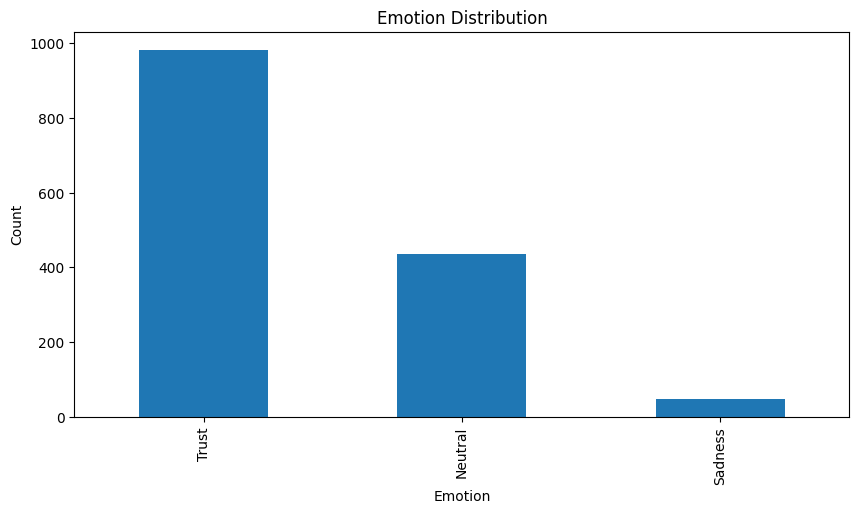

In [ ]:
plt.figure(figsize=(10,5))

emotion_counts.plot(kind='bar')

plt.title("Emotion Distribution")

plt.xlabel("Emotion")

plt.ylabel("Count")

plt.show()

In [ ]:
rating_sentiment = pd.crosstab(
    df["rating"],
    df["Sentiment"]
)

rating_sentiment

Sentiment,Negative,Neutral,Positive
rating,,,
2,0,0,1
2.3,0,1,0
2.6,0,0,1
2.8,0,0,2
2.9,0,0,1
3,1,0,0
3.0,1,0,2
3.1,0,1,3
3.2,0,0,2


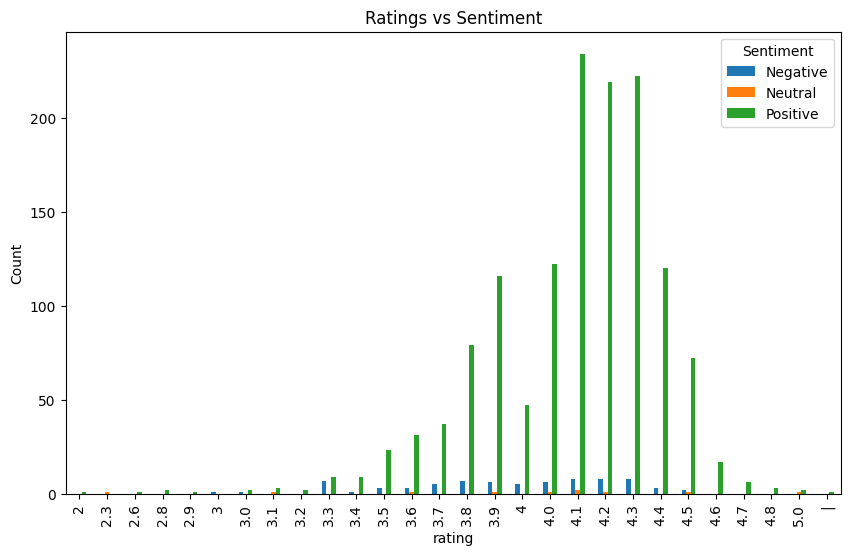

In [ ]:
rating_sentiment.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("Ratings vs Sentiment")

plt.ylabel("Count")

plt.show()

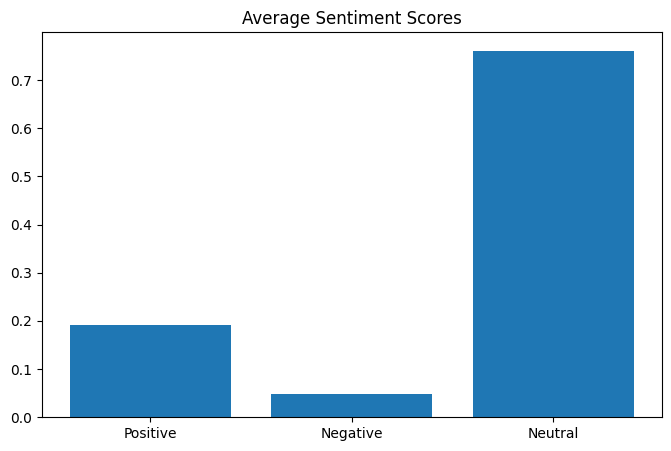

In [ ]:
avg_scores = [
    df["Positive_Score"].mean(),
    df["Negative_Score"].mean(),
    df["Neutral_Score"].mean()
]

labels = [
    "Positive",
    "Negative",
    "Neutral"
]

plt.figure(figsize=(8,5))

plt.bar(labels, avg_scores)

plt.title("Average Sentiment Scores")

plt.show()

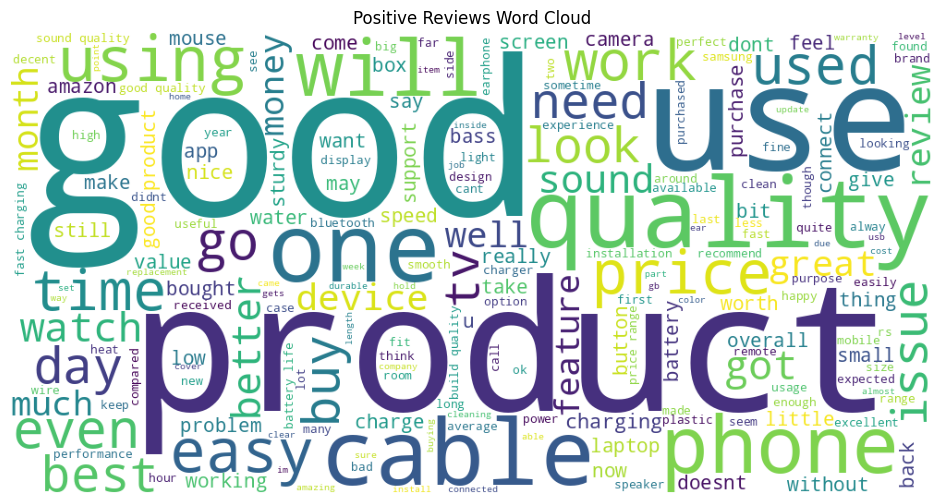

In [ ]:
positive_reviews = " ".join(
    df[df["Sentiment"]=="Positive"]["clean_review"]
)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(positive_reviews)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Positive Reviews Word Cloud")

plt.show()

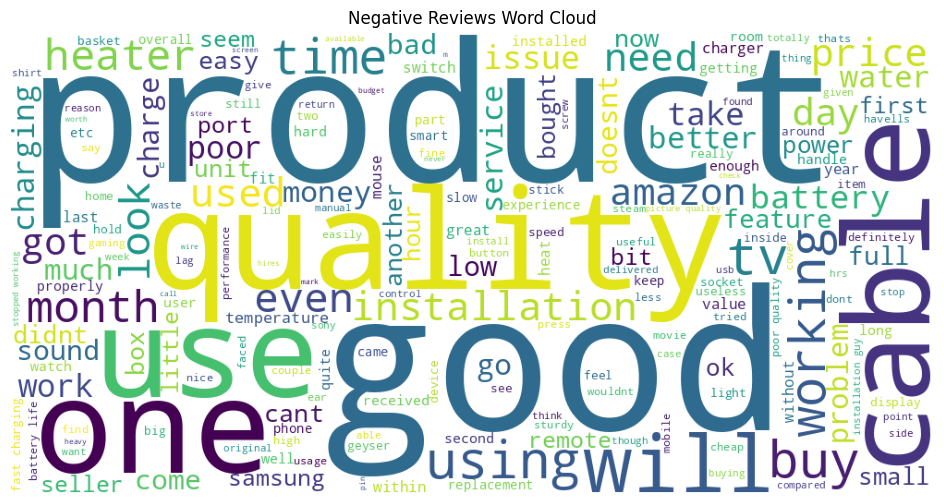

In [ ]:
negative_reviews = " ".join(
    df[df["Sentiment"]=="Negative"]["clean_review"]
)

if len(negative_reviews) > 0:

    wordcloud = WordCloud(
        width=1000,
        height=500,
        background_color='white'
    ).generate(negative_reviews)

    plt.figure(figsize=(12,6))

    plt.imshow(wordcloud)

    plt.axis("off")

    plt.title("Negative Reviews Word Cloud")

    plt.show()

/tmp/ipykernel_4505/1491768401.py:13: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


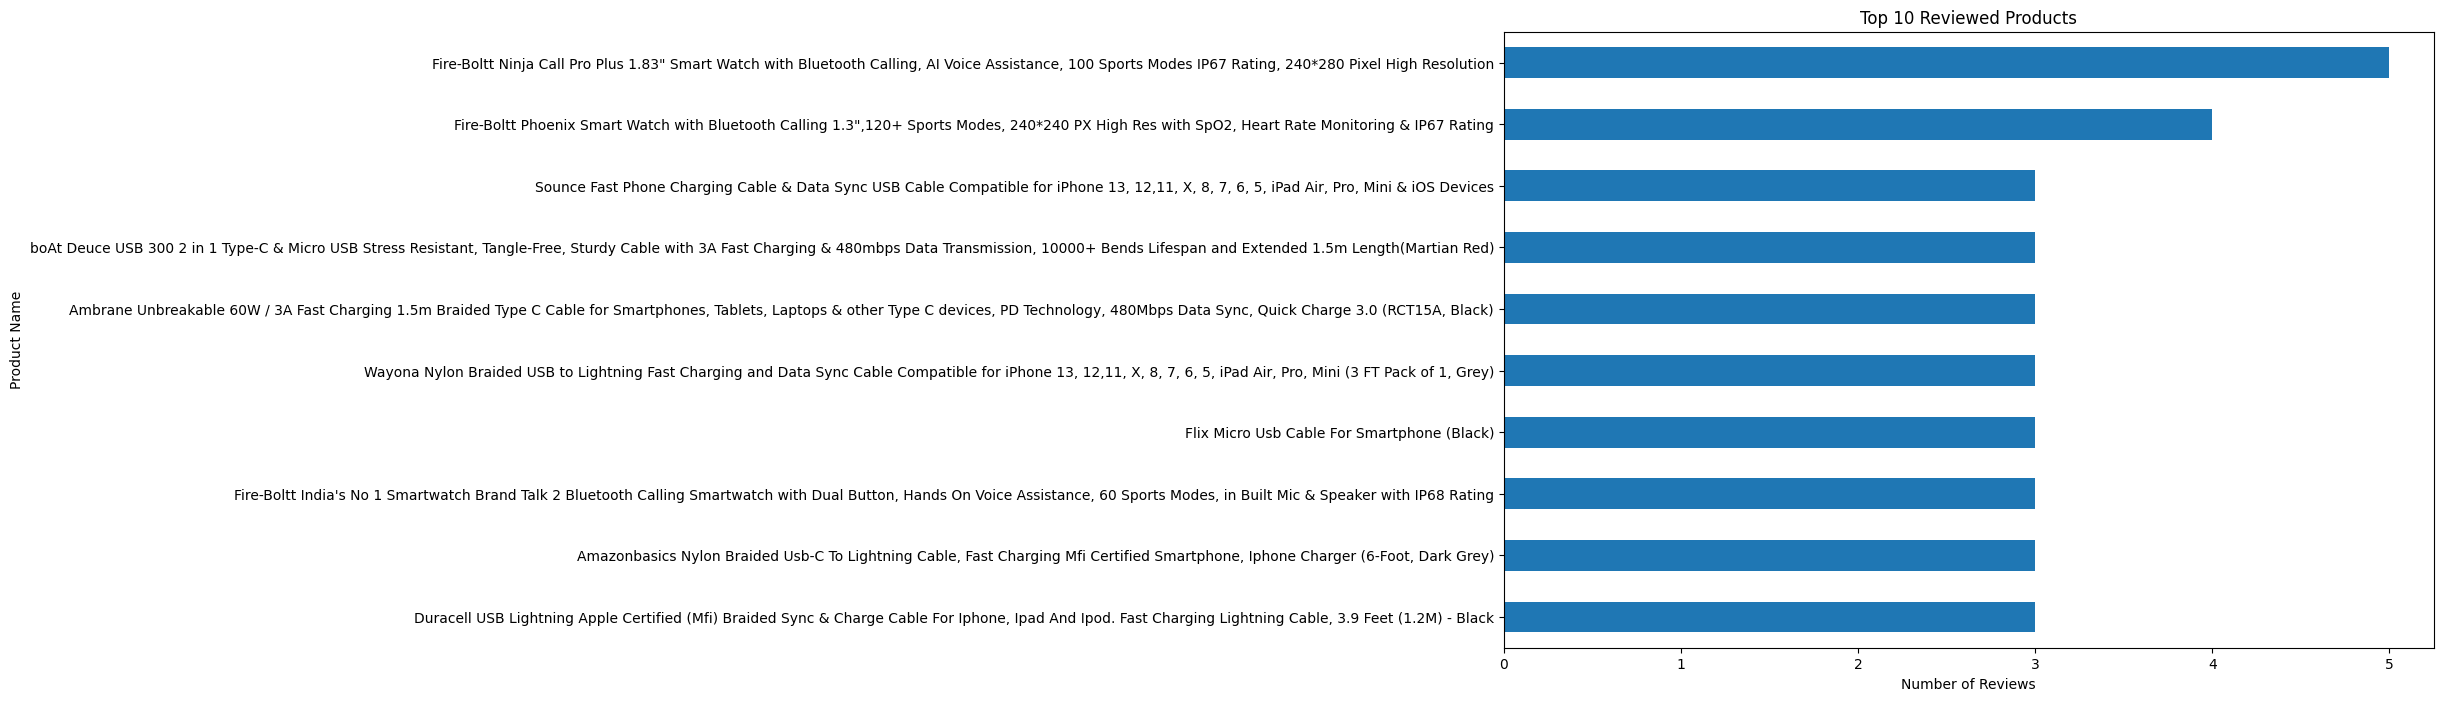

In [ ]:
top_products = df["product_name"].value_counts().head(10)

plt.figure(figsize=(12,8))

top_products.sort_values().plot(kind='barh')

plt.title("Top 10 Reviewed Products")

plt.xlabel("Number of Reviews")

plt.ylabel("Product Name")

plt.tight_layout()

plt.show()

In [ ]:
df.to_csv(
    "Amazon_Sentiment_Analysis_Output.csv",
    index=False
)

print("Output File Saved Successfully")

Output File Saved Successfully


In [ ]:
from google.colab import files

files.download('Amazon_Sentiment_Analysis_Output.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>